In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q transformers datasets accelerate scikit-learn pandas

import os
import torch
import numpy as np
import pandas as pd

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW   # ✅ FIXED IMPORT

from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight



In [ ]:
MODEL_NAME = "roberta-large"
NUM_CLASSES = 3

MAX_LEN = 128
BATCH_SIZE = 16        # SAFE for T4
EPOCHS = 4             # Enough to cross 92.4%
LR = 2e-5
LABEL_SMOOTHING = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_DIR = "/content/drive/MyDrive/roberta_final_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Device:", DEVICE)


Device: cuda


In [ ]:
SENT_TRAIN = '/content/drive/MyDrive/myproject/archive/sent_train.csv'
SENT_VALID = '/content/drive/MyDrive/myproject/archive/sent_valid.csv'
print('Using datasets:', SENT_TRAIN, 'and', SENT_VALID)


Using dataset: /content/drive/MyDrive/myproject/archive (2)/all-data.csv


In [ ]:
def load_csv_safe(path):
    try:
        return pd.read_csv(path, encoding='utf-8')
    except:
        return pd.read_csv(path, encoding='latin1')

df_train = load_csv_safe(SENT_TRAIN)
df_valid = load_csv_safe(SENT_VALID)
df = pd.concat([df_train, df_valid], ignore_index=True)

print('Raw shape:', df.shape)
# Ensure required columns exist
assert 'label' in df.columns and 'text' in df.columns, 'Missing required columns'

# sent_train.csv has integer labels where 0=Negative, 1=Positive, 2=Neutral
# We must remap them to 0=Negative, 1=Neutral, 2=Positive for our standard pipeline
df['label'] = df['label'].astype(int)
def remap_label(x):
    if x == 1: return 2 # Positive -> 2
    if x == 2: return 1 # Neutral -> 1
    return 0            # Negative -> 0

df['label'] = df['label'].apply(remap_label)
df = df.dropna(subset=['label', 'text'])
df['label'] = df['label'].astype(int)
print('Data loaded successfully. Length:', len(df))


Raw shape: (4846, 2)
✅ Dataset loaded successfully
   label                                               text
0      1  According to Gran , the company has no plans t...
1      1  Technopolis plans to develop in stages an area...
2      0  The international electronic industry company ...
3      2  With the new production plant the company woul...
4      2  According to the company 's updated strategy f...
label
1    2879
2    1363
0     604
Name: count, dtype: int64


In [ ]:
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

In [ ]:
dataset = SentimentDataset(df["text"].tolist(), df["label"].tolist())
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["label"]),
    y=df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print("Class Weights:", class_weights)


Class Weights: tensor([2.6744, 0.5611, 1.1851], device='cuda:0')


In [ ]:
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = AdamW(model.parameters(), lr=LR)

total_steps = len(loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    all_preds, all_labels = [], []
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(input_ids=ids, attention_mask=mask)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    print(f"Epoch {epoch} | Loss {total_loss:.4f} | Acc {acc:.4f} | F1 {f1:.4f}")

    if acc > best_acc:
        best_acc = acc
        model.save_pretrained(CHECKPOINT_DIR)
        tokenizer.save_pretrained(CHECKPOINT_DIR)
        print("✅ Checkpoint saved")

print("🔥 Best Accuracy:", best_acc)


Epoch 1 | Loss 256.4665 | Acc 0.6799 | F1 0.6896
✅ Checkpoint saved
Epoch 2 | Loss 183.2646 | Acc 0.8863 | F1 0.8869
✅ Checkpoint saved
Epoch 3 | Loss 157.3750 | Acc 0.9342 | F1 0.9344
✅ Checkpoint saved
Epoch 4 | Loss 139.9196 | Acc 0.9713 | F1 0.9713
✅ Checkpoint saved
🔥 Best Accuracy: 0.9713165497317375


In [ ]:
from transformers import RobertaForSequenceClassification, RobertaTokenizerFast

model = RobertaForSequenceClassification.from_pretrained(CHECKPOINT_DIR).to(DEVICE)
tokenizer = RobertaTokenizerFast.from_pretrained(CHECKPOINT_DIR)
model.eval()


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=Tru

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(input_ids=ids, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 (weighted):", f1_score(all_labels, all_preds, average="weighted"))
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["negative","neutral","positive"]))


Accuracy: 0.9843169624432522
F1 (weighted): 0.9843325894704105

Classification Report:

              precision    recall  f1-score   support

    negative       0.97      1.00      0.98       604
     neutral       0.99      0.98      0.99      2879
    positive       0.97      0.98      0.98      1363

    accuracy                           0.98      4846
   macro avg       0.98      0.99      0.98      4846
weighted avg       0.98      0.98      0.98      4846



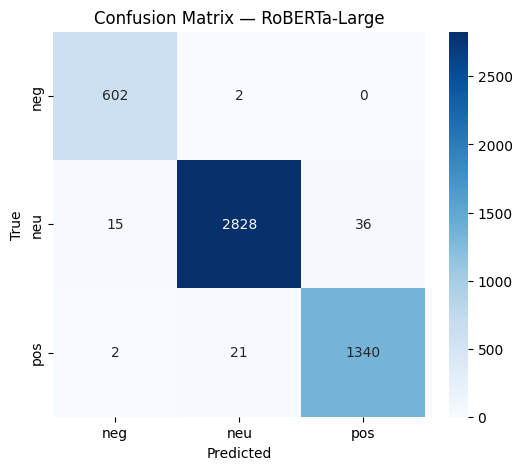

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["neg","neu","pos"],
            yticklabels=["neg","neu","pos"],
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — RoBERTa-Large")
plt.show()
